# Weekly Challenge

In [1]:
!pip install torch scikit-learn numpy pandas

In [2]:
import numpy as np
import pandas as pd

## 1. 가상 데이터셋을 생성한 뒤, 학습·검증·테스트 데이터셋으로 분할해 보세요.

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
dummy_inps = np.random.rand(1000, 3, 224, 224) # 224x224 이미지 1000장

train_ratio = .8
val_ratio = .1
test_ratio = .1
train, eval = train_test_split(dummy_inps, train_size=train_ratio)
val, test = train_test_split(eval, test_size=.5)

train.shape, val.shape, test.shape

((800, 3, 224, 224), (100, 3, 224, 224), (100, 3, 224, 224))

## 2. 가상 데이터셋을 생성하고, K-최근접이웃(K-NN) 알고리즘으로 학습·예측을 수행해 보세요.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [6]:
dummy_inps = np.random.randn(100, 1)
y = np.random.randint(low=0, high=2, size=(100, 1))

x_train, x_eval, y_train, y_eval = train_test_split(dummy_inps, y, train_size=train_ratio)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_eval = scaler.transform(x_eval)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)
knn_model.predict(x_eval)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0])

## 3. 동일한 이진 분류 가상 데이터셋을 생성하고, Perceptron, SVM, Random Forest, Naive Bayes 네 가지 알고리즘으로 학습해 보세요.

In [7]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

### Perceptron

In [8]:
weights = np.random.rand(x_train.shape[-1])
bias = np.random.rand(1)
lr = 1e-3

print("학습 전")
print(f"weights: {weights}")
print(f"bias: {bias}")

def step_func(tensor: np.ndarray):
    return 1 if tensor >= np.zeros(tensor.shape) else 0

for i in range(len(x_train)):
    y_pred = np.dot(x_train[i], weights) + bias
    y_pred = step_func(y_pred)
    error = y_train[i] - y_pred
    weights += lr * error * x_train[i]
    bias += lr * error

print("학습 후")
print(f"weights: {weights}")
print(f"bias: {bias}")

학습 전
weights: [0.14918093]
bias: [0.50217436]
학습 후
weights: [0.15131616]
bias: [0.45817436]


### SVM

In [9]:
svm_model = SVC(kernel='linear')

svm_model.fit(x_train, y_train)
svm_model.predict(x_eval)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Random Forest

In [10]:
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
rf_model.predict(x_eval)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array([0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0])

### Naive Bayes

In [11]:
nb_model = GaussianNB()

nb_model.fit(x_train, y_train)
nb_model.predict(x_eval)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0])

## 5. 활성화 함수를 직접 정의하고, 활성화 함수를 적용한 출력을 계산하고, 결과를 그래프로 시각화하세요.

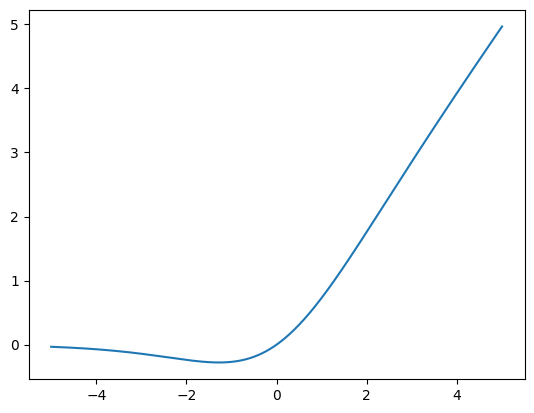

In [12]:
import torch
import matplotlib.pyplot as plt


def SiLU(x: torch.Tensor):
    return x * (1 / (1 + torch.exp(-x)))


x = torch.linspace(-5, 5, 1000)
plt.plot(x, SiLU(x))

plt.show()

아래의 주제들을 CIFAR-100(비선형 이미지) 데이터셋을 통해 같이 다루었습니다.

- ## 4. 가상 데이터셋을 준비하고, 증강(Data Augmentation) 기법을 적용했을 때와 적용하지 않았을 때 모델 성능을 비교하세요.
- ## 6. 비선형 데이터셋을 생성하고, MLP(다층 퍼셉트론) 모델을 설계하고 학습시켜 분류를 수행하세요.
- ## 7. CNN(Convolutional Neural Network)을 직접 구성하여 이미지 분류를 수행하세요.

In [13]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
# 하이퍼파라미터
hyper_params = {
    "img_size": (32, 32), # (height, width)
    "batch_size": 256,
    "num_workers": 2,
    "epochs": 20,
    "lr": 5e-4,
    "weight_decay": 1e-3,
    "min_scale": .5,
    "max_scale": 1.,
    "in_chans": 3,
    "embed_dim": 128,
    "n_classes": 10,
    "seed": 42,
    "device": "cuda",
}

In [15]:
# seed 고정
seed = hyper_params.get("seed", 42)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

In [16]:
cifar10_mean = torch.tensor([0.4914, 0.4822, 0.4465])
cifar10_std = torch.tensor([0.2470, 0.2435, 0.2616])

# 학습용 데이터 변환
train_transform = transforms.Compose([
    transforms.Resize(hyper_params["img_size"]),
    transforms.ToTensor(), # PIL -> Tensor
    transforms.Normalize(cifar10_mean, cifar10_std) # mean, std
])
# 학습용 데이터 변환(+ 증강)
train_aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(hyper_params["img_size"], scale=(hyper_params["min_scale"], hyper_params["max_scale"])),
    transforms.RandomHorizontalFlip(.5),
    transforms.ToTensor(), # PIL -> Tensor
    transforms.Normalize(cifar10_mean, cifar10_std) # mean, std
])
# 평가용 데이터 변환
eval_transform = transforms.Compose([
    transforms.CenterCrop(hyper_params["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std) # mean, std
])

In [ ]:
def make_dataloader(train_transform: transforms.Compose, eval_transform: transforms.Compose | None = None, h_params: dict = {}) -> tuple[DataLoader, DataLoader | None]:
    """학습 및 평가용 데이터 변환과 하이퍼파라미터를 입력으로 받아 학습 및 평가용 데이터 로더를 반환하는 함수"""    
    train_dataset = datasets.CIFAR10(root='./data', train=True, transform=train_transform, download=True)
    eval_dataset = datasets.CIFAR10(root='./data', train=False, transform=eval_transform, download=True)
    g = torch.Generator() # 증강 ablation을 위해 사용
    g.manual_seed(h_params.get("seed", 42))
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=h_params["batch_size"],
        shuffle=True,
        drop_last=True,
        num_workers=h_params["num_workers"],
        pin_memory=True,
        persistent_workers=True,
        generator=g,
    )
    eval_dataloader = None
    if eval_transform is not None:
        eval_dataloader = DataLoader(
            eval_dataset,
            batch_size=h_params["batch_size"],
            shuffle=False,
            drop_last=False,
            num_workers=h_params["num_workers"],
            pin_memory=True,
            persistent_workers=True,
        )
    return train_dataloader, eval_dataloader

In [ ]:
def denormalize(tensor: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """시각화를 위해 역정규화된 tensor를 반환하는 함수"""
    return tensor * std.view(3, 1, 1) + mean.view(3, 1, 1)

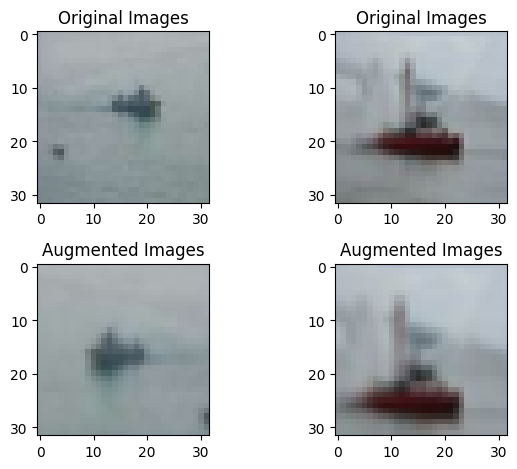

In [19]:
train_dataloader, eval_dataloader = make_dataloader(train_transform, eval_transform, hyper_params)
train_aug_dataloader, _ = make_dataloader(train_aug_transform, h_params=hyper_params)

for (imgs, _), (imgs_aug, _) in zip(train_dataloader, train_aug_dataloader):
    imgs = denormalize(imgs, cifar10_mean, cifar10_std) # (B, C, H, W)
    imgs_aug = denormalize(imgs_aug, cifar10_mean, cifar10_std) # (B, C, H, W)

    B, C, H, W = imgs.shape # batch size, channel, height, width
    n = min(B, 2)
    fig, axes = plt.subplots(2, n) # 2개 정도까지만 시각화
    if n == 1:
        axes = [axes]
    
    for i in range(n):
        # 원본
        img = imgs[i].permute(1, 2, 0).numpy() # (H, W, C)
        axes[0, i].imshow(img)
        axes[0, i].set_title("Original Images")

        # 증강
        img_aug = imgs_aug[i].permute(1, 2, 0).numpy() # (H, W, C)
        axes[1, i].imshow(img_aug)
        axes[1, i].set_title("Augmented Images")
    plt.tight_layout()
    plt.show()
    break

In [20]:
# MLP 모델 정의
class MLP(nn.Module):
    def __init__(self, in_chans: int, hidden_size: int, n_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(in_chans, hidden_size)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_size, n_classes)

    def forward(self, x: torch.Tensor):
        B, C, H, W = x.shape
        x = x.mean(dim=[2, 3]) # pooling
        return self.fc2(self.act(self.fc1(x)))
    
# test
device = hyper_params.get("device", "cpu")
mlp = MLP(3, 128, 10).to(device=device)
mlp(torch.rand(2, 3, 32, 32).to(device=device)).shape

torch.Size([2, 10])

In [21]:
# CNN 모델 정의
class SimpleCNN(nn.Module):
    def __init__(self, in_chans: int, embed_dim: int, n_classes: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_chans, embed_dim // 2, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim // 2),
            nn.GELU(),
            nn.Conv2d(embed_dim // 2, embed_dim // 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(embed_dim // 2),
            nn.GELU(),
            nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim),
            nn.GELU(),
            nn.Conv2d(embed_dim, embed_dim, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(embed_dim)
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x: torch.Tensor):
        B, C, H, W = x.shape
        x = self.proj(x)
        x = x.flatten(2) # (B, C, HW)
        x = x.permute(0, 2, 1) # (B, HW, C)
        x = self.norm(x) # (B, HW, C)
        return self.head(x.mean(dim=1)) # (B, n_classes)
    
# test
cnn = SimpleCNN(3, 128, 10).to(device)
cnn(torch.rand(2, 3, 32, 32).to(device)).shape

torch.Size([2, 10])

In [22]:
in_chans = hyper_params["in_chans"]
embed_dim = hyper_params["embed_dim"]
n_classes = hyper_params["n_classes"]

# 모델 초기화
mlp = MLP(in_chans=in_chans, hidden_size=embed_dim, n_classes=n_classes).to(device)
cnn = SimpleCNN(in_chans=in_chans, embed_dim=embed_dim, n_classes=n_classes).to(device)

In [23]:
def train_one_epoch(model, criterion, dataloader, optimizer):
    """한 epoch 학습"""
    model.train()

    for samples, targets in dataloader:
        samples = samples.to(non_blocking=True, device=device)
        targets = targets.to(non_blocking=True, device=device)

        outputs = model(samples) # forward
        loss = criterion(outputs, targets) # 손실 계산

        optimizer.zero_grad()
        loss.backward() # Backpropagation
        optimizer.step() # 가중치 갱신

@torch.no_grad()
def evaluate(model, dataloader, criterion, device="cpu"):
    """평가 함수"""
    model.eval()
    total_loss, correct, total = 0., 0, 0 # 손실값, 맞은 개수, 전체 샘플 수

    for samples, targets in dataloader:
        samples = samples.to(non_blocking=True, device=device)
        targets = targets.to(non_blocking=True, device=device)

        outputs = model(samples)
        loss = criterion(outputs, targets) # 배치 평균 손실값

        total_loss += loss.item() * targets.shape[0] # 손실값 전체
        correct += (outputs.argmax(dim=-1) == targets).sum().item() # scalar로 기록
        total += targets.shape[0]
    
    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc

In [24]:
lr = hyper_params["lr"]
weight_decay = hyper_params["weight_decay"]

# MLP 학습
optimizer = optim.AdamW(mlp.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()

epochs = hyper_params["epochs"]
for _ in range(epochs):
    train_one_epoch(mlp, criterion, train_dataloader, optimizer)

# MLP 평가
val_loss, val_acc = evaluate(mlp, eval_dataloader, criterion, device)
val_loss, val_acc

(2.0202722408294678, 0.2518)

In [25]:
lr = hyper_params["lr"]
weight_decay = hyper_params["weight_decay"]

# CNN(증강 X) 학습 및 평가
optimizer = optim.AdamW(cnn.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()

val_losses, val_accs = [], []
for _ in range(epochs):
    train_one_epoch(cnn, criterion, train_dataloader, optimizer)
    val_loss, val_acc = evaluate(cnn, eval_dataloader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
val_losses[-1], val_accs[-1]

(1.1967984386444093, 0.6749)

In [26]:
cnn_aug = SimpleCNN(in_chans=in_chans, embed_dim=embed_dim, n_classes=n_classes).to(device)

# CNN(증강 O) 학습 및 평가
optimizer_aug = optim.AdamW(cnn_aug.parameters(), lr=lr, weight_decay=weight_decay)

val_aug_losses, val_aug_accs = [], []
for _ in range(epochs):
    train_one_epoch(cnn_aug, criterion, train_aug_dataloader, optimizer_aug)
    val_aug_loss, val_aug_acc = evaluate(cnn_aug, eval_dataloader, criterion, device)
    val_aug_losses.append(val_aug_loss)
    val_aug_accs.append(val_aug_acc)
val_aug_losses[-1], val_aug_accs[-1]

(0.8142859014511108, 0.7228)

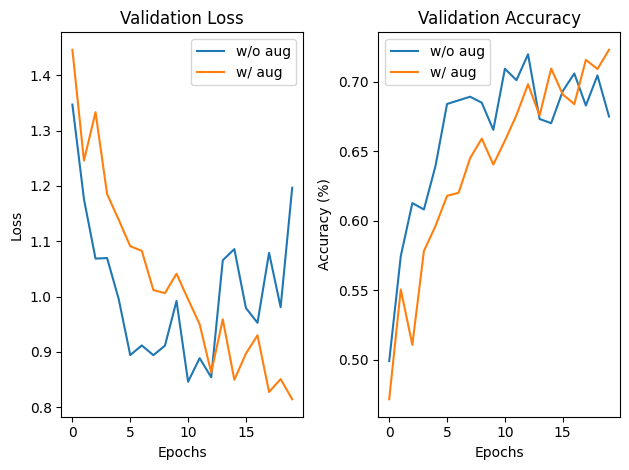

In [27]:
# 증강 유무에 따른 시각화 비교
fig, axes = plt.subplots(1, 2)

# 손실
axes[0].plot(range(epochs), val_losses, label="w/o aug")
axes[0].plot(range(epochs), val_aug_losses, label="w/ aug")
axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

# 정확도
axes[1].plot(range(epochs), val_accs, label="w/o aug")
axes[1].plot(range(epochs), val_aug_accs, label="w/ aug")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()


plt.tight_layout()
plt.show()